In [1]:
from myutils import *
plt.rcdefaults()
from src import *

In [2]:
width = 8.5 / 2.54 #inches

plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath, amssymb, physics, microtype}'

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))

pm_params = {
    'marker': 'o',
    'edgecolors': 'tab:blue',
    'facecolors': 'none',
    's': 7,
    'linewidths': 0.5
}

hg_params = {
    'marker': 'D',
    'edgecolors': 'tab:green',
    'facecolors': 'none',
    's': 5,
    'linewidths': 0.5
}

di_params = {
    'marker': '+',
    'facecolor': 'k',
    's': 9,
    'linewidths': 0.5
}

c_red = 'tab:orange'
# c_red = 'r'

In [4]:
@cache
def run_sim_fig4():
    sim = Simulator('hg', DMD.A(5), 0.2)

    hg_mean, hg_var = [], []
    for b_prime in np.linspace(0, 0.1, 30):
        c = sim.gen(b_prime*60, 60)
        c.est()
        hg_mean.append(c.estimates.mean())
        hg_var.append(c.photons * c.estimates.var(0, ddof=1))

    sim = Simulator('pm', DMD.A(5), 0.2)

    pm_mean, pm_var = [], []
    for b_prime in np.linspace(0, 0.1, 30):
        c = sim.gen(b_prime*60, 60)
        c.est()
        pm_mean.append(c.estimates.mean())
        pm_var.append(c.photons * c.estimates.var(0, ddof=1))

    sim = Simulator('di', DMD.A(5), 0.2)

    di_mean, di_var = [], []
    for b_prime in np.linspace(0, 0.1, 30):
        c = sim.gen(b_prime*400, 400)
        c.est()
        di_mean.append(c.estimates.mean())
        di_var.append(c.photons * c.estimates.var(0, ddof=1))

    means = [hg_mean, pm_mean, di_mean]
    vars = [hg_var, pm_var, di_var]
    return means, vars


In [5]:
# means, vars = run_sim_fig4()

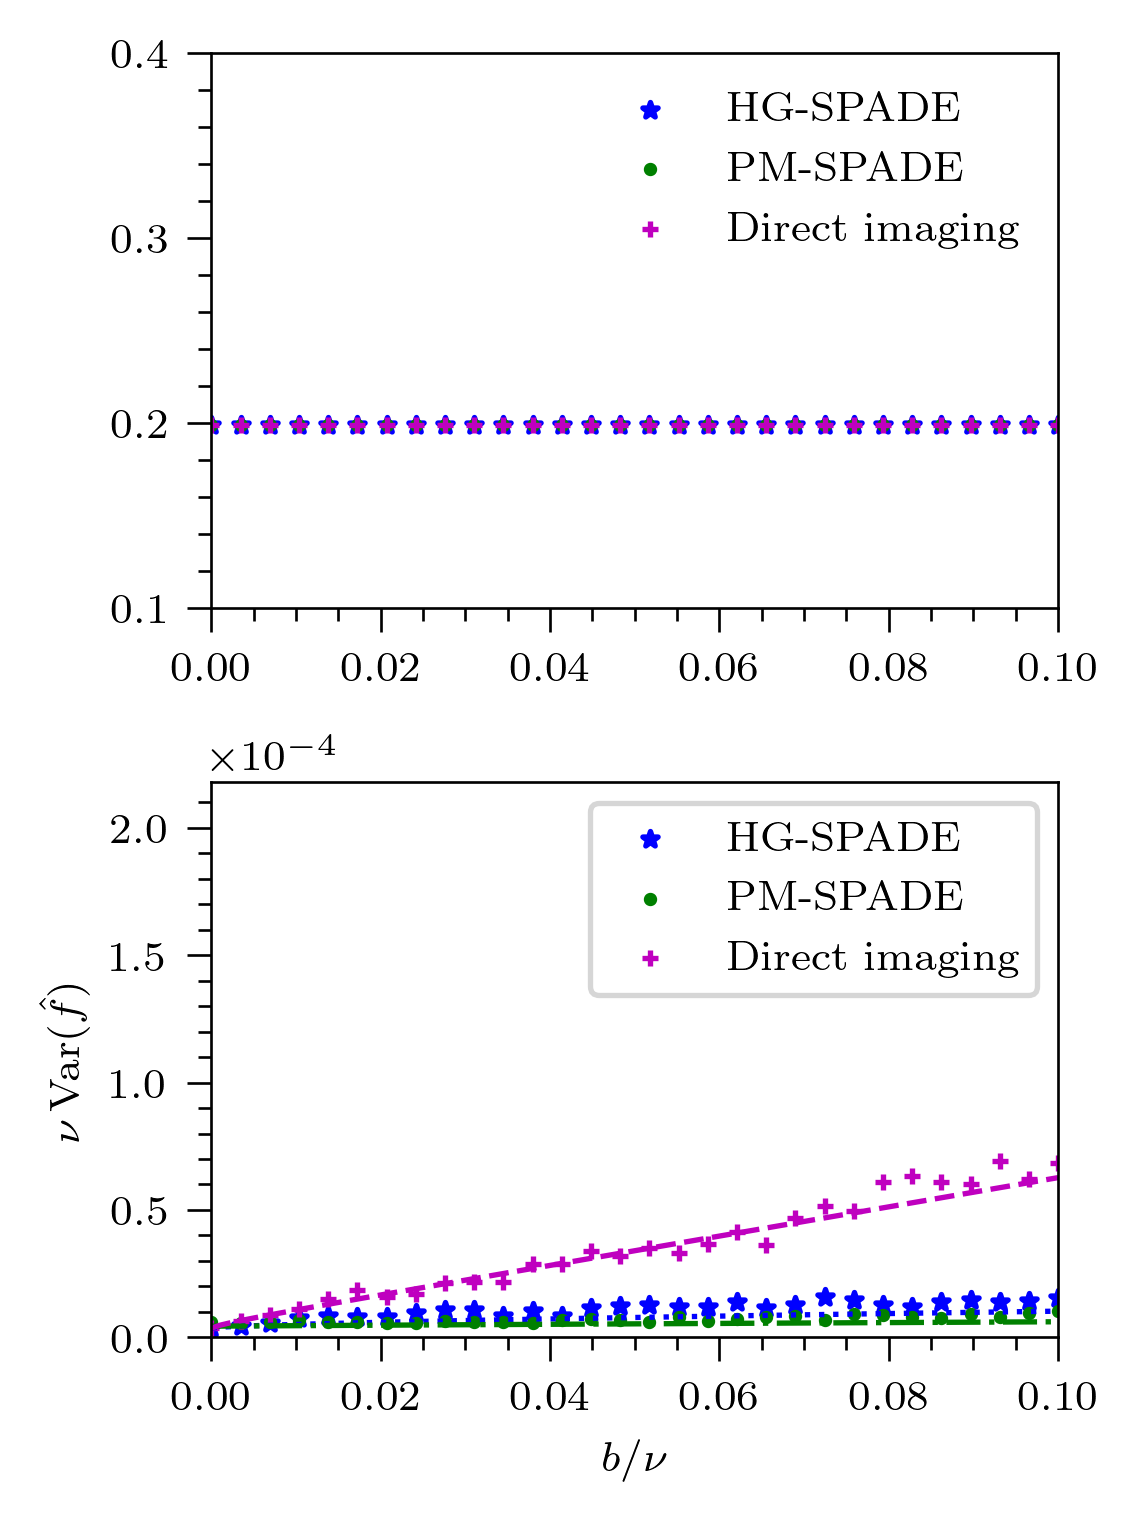

In [6]:
# plt.rcParams['figure.figsize'] = (3, 4)

# plt.subplot(2, 1, 1) 

# plt.scatter(np.linspace(0, 0.1, 30), np.array(means[0]), marker='*', color='b', label=r'HG-SPADE')
# plt.scatter(np.linspace(0, 0.1, 30), np.array(means[1]), marker='.', color='g', label=r'PM-SPADE')
# plt.scatter(np.linspace(0, 0.1, 30), np.array(means[2]), marker='+', color='m', label=r'Direct imaging')

# plt.legend(frameon=False)
# plt.xlim(0, 0.1)
# plt.ylim(0.1, 0.4)

# plt.subplot(2, 1, 2)

# plt.scatter(np.linspace(0, 0.1, 30), np.array(vars[0]), marker='*', color='b', label=r'HG-SPADE')
# plt.scatter(np.linspace(0, 0.1, 30), np.array(vars[1]), marker='.', color='g', label=r'PM-SPADE')
# plt.scatter(np.linspace(0, 0.1, 30), np.array(vars[2]), marker='+', color='m', label=r'Direct imaging')

# plt.plot(np.linspace(0, 0.1, 100), 1/HG_SPADE.CFI(np.linspace(0, 0.1, 100), (4/pi) * DMD.A(5), 0.2), 'b:')
# plt.plot(np.linspace(0, 0.1, 100), 1/PM_SPADE.CFI(np.linspace(0, 0.1, 100), (4/pi) * DMD.A(5), 0.2), 'g-.')
# plt.plot(np.linspace(0, 0.1, 100), 1/DI.CFI(np.linspace(0, 0.1, 100), (4/pi) * DMD.A(5), 0.2), 'm--')

# plt.xlabel(r'$b/\nu$')
# plt.ylabel(r'$\nu \operatorname{Var}(\hat f)$')
# plt.legend()
# plt.xlim(0, 0.1)
# plt.ylim(0, 2.18e-4)

# plt.gca().yaxis.set_major_formatter(formatter)
# plt.tight_layout()
# plt.show()

In [5]:
@cache
def run_sim_fig3():
    hg_mean, hg_var = [], []
    for f in np.linspace(0.1, 0.4, 61):
        c = Simulator('hg', DMD.A(5), f).gen()
        c.est()
        hg_mean.append(c.estimates.mean())
        hg_var.append(c.estimates.var() * c.photons)


    pm_mean, pm_var = [], []
    for f in np.linspace(0.1, 0.4, 61):
        c = Simulator('pm', DMD.A(5), f).gen()
        c.est()
        pm_mean.append(c.estimates.mean())
        pm_var.append(c.estimates.var() * c.photons)


    di_mean, di_var = [], []
    for f in np.linspace(0.1, 0.4, 61):
        c = Simulator('di', DMD.A(5), f).gen()
        c.est()
        di_mean.append(c.estimates.mean())
        di_var.append(c.estimates.var() * c.photons)

    means = [hg_mean, pm_mean, di_mean]
    vars = [hg_var, pm_var, di_var]
    return means, vars

In [6]:
means1, vars1 = run_sim_fig3()
means2, vars2 = run_sim_fig4()

cache hit: reading result from cache file
cache hit: reading result from cache file


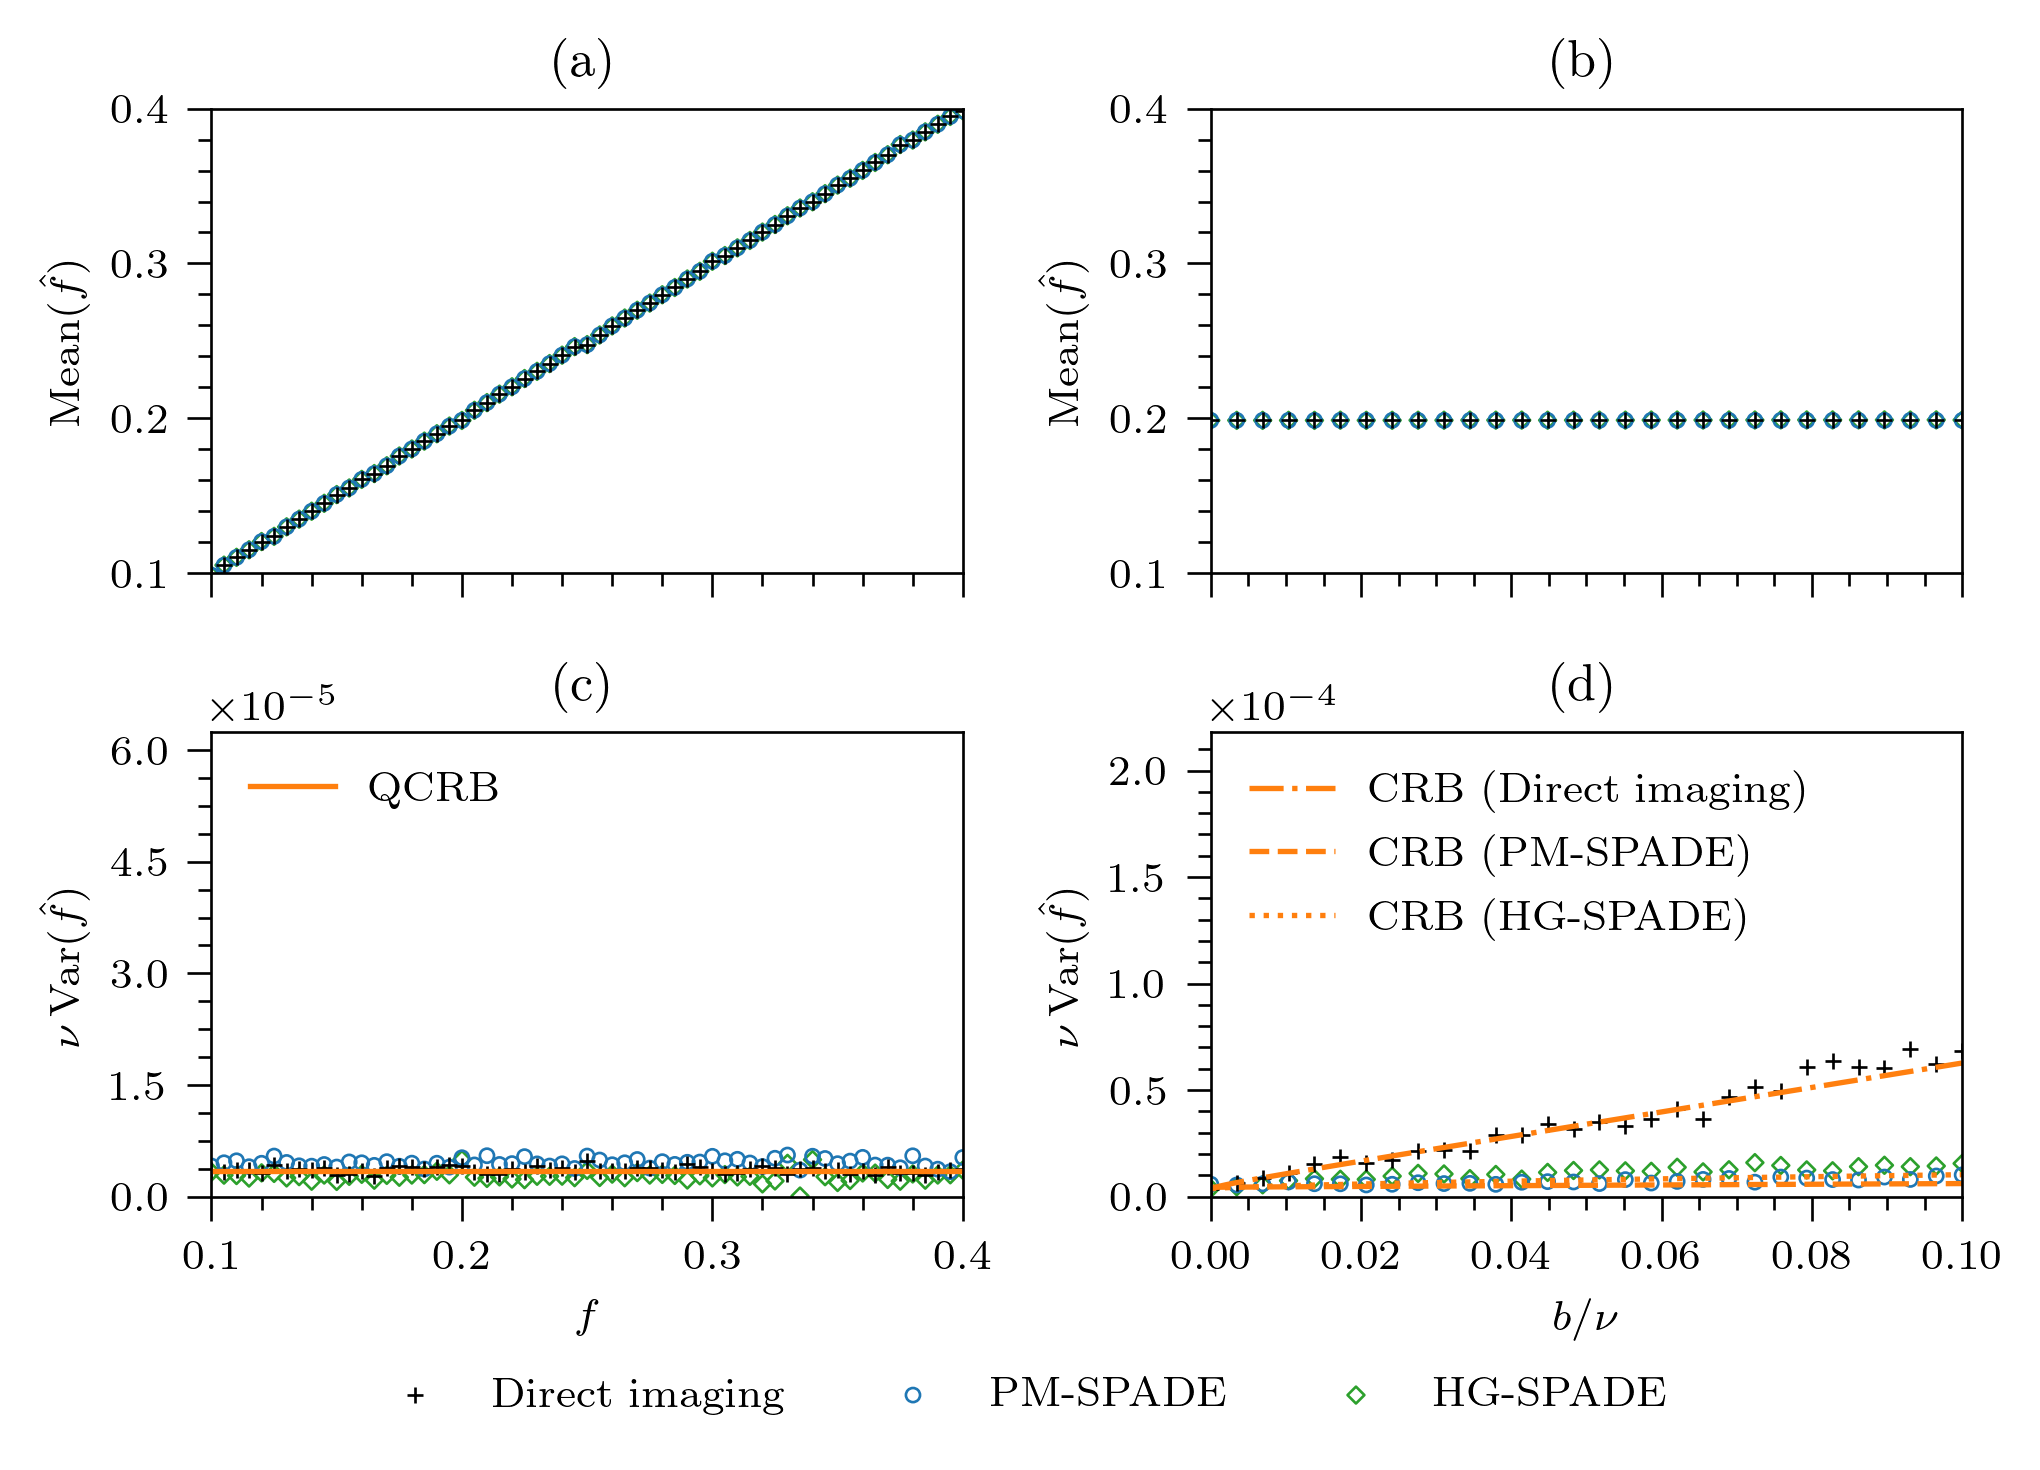

In [82]:
fig, axes = plt.subplots(2, 2, figsize=(width*1.6, width*1.1), sharex='col', sharey=False)

for ax in axes.ravel():
    ax.set_box_aspect(0.618)

axes[0, 0].set_ylabel(r'$\operatorname{Mean}(\hat f)$')
axes[1, 0].set_ylabel(r'$\nu\operatorname{Var}(\hat f)$')

axes[1, 0].set_xlabel(r'$f$')
axes[1, 1].set_xlabel(r'$b/\nu$')

axes[0, 0].set_title(r'$\rm (a)$')
axes[0, 1].set_title(r'$\rm (b)$')
axes[1, 0].set_title(r'$\rm (c)$')
axes[1, 1].set_title(r'$\rm (d)$')

axes[0, 0].scatter(np.linspace(0.1, 0.4, 61), np.array(means1[0]), label=r'HG-SPADE', **hg_params)
axes[0, 0].scatter(np.linspace(0.1, 0.4, 61), np.array(means1[1]), label=r'PM-SPADE', **pm_params)
axes[0, 0].scatter(np.linspace(0.1, 0.4, 61), np.array(means1[2]), label=r'Direct imaging', **di_params)
axes[0, 0].set_xlim(0.1, 0.4)
axes[0, 0].set_ylim(0.1, 0.4)

axes[1, 0].scatter(np.linspace(0.1, 0.4, 61), np.array(vars1[0]), label=r'HG-SPADE', **hg_params)
axes[1, 0].scatter(np.linspace(0.1, 0.4, 61), np.array(vars1[1]), label=r'PM-SPADE', **pm_params)
axes[1, 0].scatter(np.linspace(0.1, 0.4, 61), np.array(vars1[2]), label=r'Direct imaging', **di_params)
axes[1, 0].set_xlim(0.1, 0.4)
axes[1, 0].set_ylim(0, 1.04*6e-5)

axes[0, 0].set_xticks(np.linspace(0.1, 0.4, 4))
axes[0, 0].set_yticks(np.linspace(0.1, 0.4, 4))

qcrb = axes[1, 0].axhline(1/DI.ApproxCFI((4/pi) * DMD.A(5)), color=c_red, zorder=2)
axes[1, 0].set_yticks(np.linspace(0, 6, 5) * 1e-5)
axes[1, 0].yaxis.set_major_formatter(formatter)
axes[1, 0].legend([qcrb], ['QCRB'], frameon=False, loc='upper left')



axes[0, 1].scatter(np.linspace(0, 0.1, 30), np.array(means2[0]), label=r'HG-SPADE', **hg_params)
axes[0, 1].scatter(np.linspace(0, 0.1, 30), np.array(means2[1]), label=r'PM-SPADE', **pm_params)
axes[0, 1].scatter(np.linspace(0, 0.1, 30), np.array(means2[2]), label=r'Direct imaging', **di_params)
axes[0, 1].set_xlim(0, 0.1)
axes[0, 1].set_ylim(0.1, 0.4)

hg_ = axes[1, 1].scatter(np.linspace(0, 0.1, 30), np.array(vars2[0]), label=r'HG-SPADE', **hg_params)
pm_ = axes[1, 1].scatter(np.linspace(0, 0.1, 30), np.array(vars2[1]), label=r'PM-SPADE', **pm_params)
di_ = axes[1, 1].scatter(np.linspace(0, 0.1, 30), np.array(vars2[2]), label=r'Direct imaging', **di_params)
axes[1, 1].set_xlim(0, 0.1)
axes[1, 1].set_ylim(0, 2.18e-4)

hg_crb, = axes[1, 1].plot(np.linspace(0, 0.1, 100), 1/HG_SPADE.CFI(np.linspace(0, 0.1, 100), (4/pi) * DMD.A(5), 0.2), ':', color=c_red, zorder=2)
pm_crb, = axes[1, 1].plot(np.linspace(0, 0.1, 100), 1/PM_SPADE.CFI(np.linspace(0, 0.1, 100), (4/pi) * DMD.A(5), 0.2), '--', color=c_red, zorder=2)
di_crb, = axes[1, 1].plot(np.linspace(0, 0.1, 100), 1/DI.CFI(np.linspace(0, 0.1, 100), (4/pi) * DMD.A(5), 0.2), '-.', color=c_red, zorder=2)
axes[1, 1].legend([di_crb, pm_crb, hg_crb], ['CRB (Direct imaging)', 'CRB (PM-SPADE)', 'CRB (HG-SPADE)'], frameon=False, loc='upper left')

axes[1, 1].set_ylim(0, 2.18e-4)
axes[1, 1].yaxis.set_major_formatter(formatter)
axes[0, 1].set_ylabel(r'$\operatorname{Mean}(\hat f)$')
axes[1, 1].set_ylabel(r'$\nu \operatorname{Var}(\hat f)$')



# fig.legend([di_, pm_, hg_, qcrb, di_crb, pm_crb, hg_crb], 
#            ['Direct imaging', 'PM-SPADE', 'HG-SPADE', 'QCRB', 'CRB (Direct imaging)', 'CRB (PM-SPADE)', 'CRB (HG-SPADE)'],
#             ncol=1, loc='upper right', bbox_to_anchor=(1.45, 0.92), frameon=False)

fig.legend([di_, pm_, hg_], 
           ['Direct imaging', 'PM-SPADE', 'HG-SPADE'],
           ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.04), frameon=False)

plt.tight_layout()
plt.savefig('sim2.pdf')
plt.show()

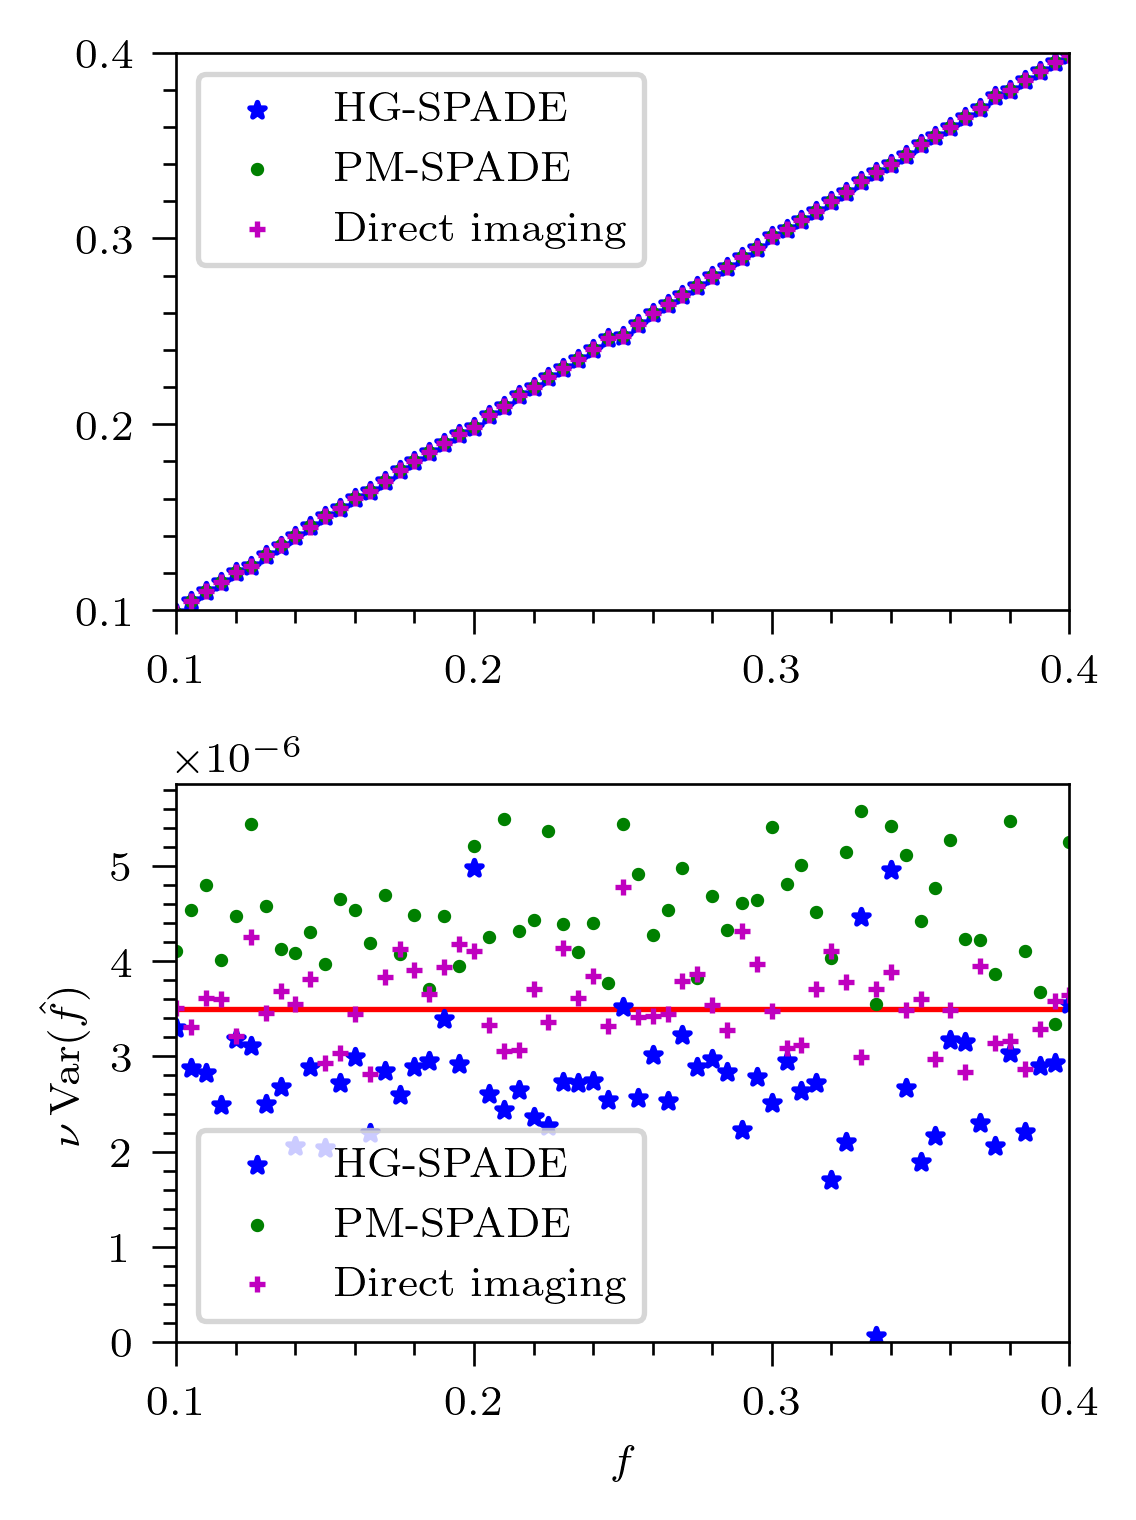

In [9]:
# plt.rcParams['figure.figsize'] = (3, 4)

# plt.subplot(2, 1, 1)

# plt.scatter(np.linspace(0.1, 0.4, 61), np.array(means[0]), marker='*', color='b', label=r'HG-SPADE')
# plt.scatter(np.linspace(0.1, 0.4, 61), np.array(means[1]), marker='.', color='g', label=r'PM-SPADE')
# plt.scatter(np.linspace(0.1, 0.4, 61), np.array(means[2]), marker='+', color='m', label=r'Direct imaging')

# plt.legend(frameon=True)
# plt.xlim(0.1, 0.4)
# plt.ylim(0.1, 0.4)

# plt.subplot(2, 1, 2)

# plt.scatter(np.linspace(0.1, 0.4, 61), np.array(vars[0]), marker='*', color='b', label=r'HG-SPADE')
# plt.scatter(np.linspace(0.1, 0.4, 61), np.array(vars[1]), marker='.', color='g', label=r'PM-SPADE')
# plt.scatter(np.linspace(0.1, 0.4, 61), np.array(vars[2]), marker='+', color='m', label=r'Direct imaging')

# plt.axhline(1/DI.ApproxCFI((4/pi) * DMD.A(5)), color='red', zorder=0)
# plt.xlim(0.1, 0.4)
# plt.ylim(0, None)

# plt.xlabel(r'$f$')
# plt.ylabel(r'$\nu \operatorname{Var}(\hat f)$')
# # plt.title(r'$A=0.47\sigma$')
# plt.legend(frameon=True)

# plt.tight_layout()
# plt.show()